In [1]:
import numpy as np
import matplotlib.pyplot as plt
import string
import os


plt.rcParams.update(
    {
        "font.size": 11,  # base font size (tick labels)
        "axes.labelsize": 13,  # axis labels
        "axes.titlesize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.dpi": 300,
    }
)

import jax.numpy as jnp
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("cpu")[0])

# Import your optimization and plotting utilities
from optimization_core import (
    build_jsa_grid,
    penalty_continuation_grad_desc,
    load_results,
    to_complex,
    tensor_knapsack_bound,
)

In [2]:
# ---------------------------------------------------------
# 1. Experiment parameters
# ---------------------------------------------------------

# Parameters for the multivariate normal distribution
n = 60  # Number of points in the frequency grid nxnxn
d = 3  # Dimensionality of the problem
mean = jnp.zeros(d)  # Mean
x_lim = 4  # Limits in x and y ax0is for plotting

# # Sweep parameters
n_steps = 80  # Number of steps in the sweep
rho_values = jnp.linspace(
    -0.49, 0.99, n_steps
)  # rho_values is analogous to the correlation coefficients in the correlation matrix

In [3]:
sigma_list = []
eta_list = []
upper_bound_list = []

for i, rho_value in enumerate(rho_values):
    # ---------------------------------------------------------
    # 1. Export data
    # ---------------------------------------------------------
    filename = f"eigen_eval_results_{d}D_20260615_r_{rho_value:.2f}.pkl"
    if os.path.exists("results_data/" + filename):
        df, _, _ = load_results(filename)
        f_pen = df["optim_lo"]
        fun_pen = df["eta"]

        # ---------------------------------------------------------
        # 2. Build JSA grid and initial mode
        # ---------------------------------------------------------
        print("Building JSA grid...")
        _, jsa_data = build_jsa_grid(n, mean, rho_value, x_lim)
        jsa_flat = jnp.reshape(jsa_data, (n, n ** (d - 1)))
        u, s, vt = jax.scipy.linalg.svd(jsa_flat, full_matrices=False)

        bound, tau_opt, sigma, mu, v_caps = tensor_knapsack_bound(jsa_data)

        # Compute bounds
        upper_bound = bound
        sigma_1 = s[0]

        # Print results
        print(rf"Actual $\eta$: {fun_pen:.4f}")
        print(f"Actual sigma_1: {sigma_1:.4f}")
        print(f"Upper bound: {jnp.abs(upper_bound):.4f}")
        sigma_list.append(sigma_1)
        eta_list.append(fun_pen)
        upper_bound_list.append(upper_bound)

Building JSA grid...
Actual $\eta$: 0.5384
Actual sigma_1: 0.6240
Upper bound: 0.5866
Building JSA grid...
Actual $\eta$: 0.6819
Actual sigma_1: 0.7559
Upper bound: 0.7117
Building JSA grid...
Actual $\eta$: 0.7549
Actual sigma_1: 0.8175
Upper bound: 0.7740
Building JSA grid...
Actual $\eta$: 0.8031
Actual sigma_1: 0.8564
Upper bound: 0.8164
Building JSA grid...
Actual $\eta$: 0.8384
Actual sigma_1: 0.8839
Upper bound: 0.8477
Building JSA grid...
Actual $\eta$: 0.8656
Actual sigma_1: 0.9046
Upper bound: 0.8724
Building JSA grid...
Actual $\eta$: 0.8874
Actual sigma_1: 0.9209
Upper bound: 0.8923
Building JSA grid...
Actual $\eta$: 0.9053
Actual sigma_1: 0.9340
Upper bound: 0.9088
Building JSA grid...
Actual $\eta$: 0.9202
Actual sigma_1: 0.9447
Upper bound: 0.9227
Building JSA grid...
Actual $\eta$: 0.9327
Actual sigma_1: 0.9537
Upper bound: 0.9346
Building JSA grid...
Actual $\eta$: 0.9434
Actual sigma_1: 0.9612
Upper bound: 0.9447
Building JSA grid...
Actual $\eta$: 0.9526
Actual sigm

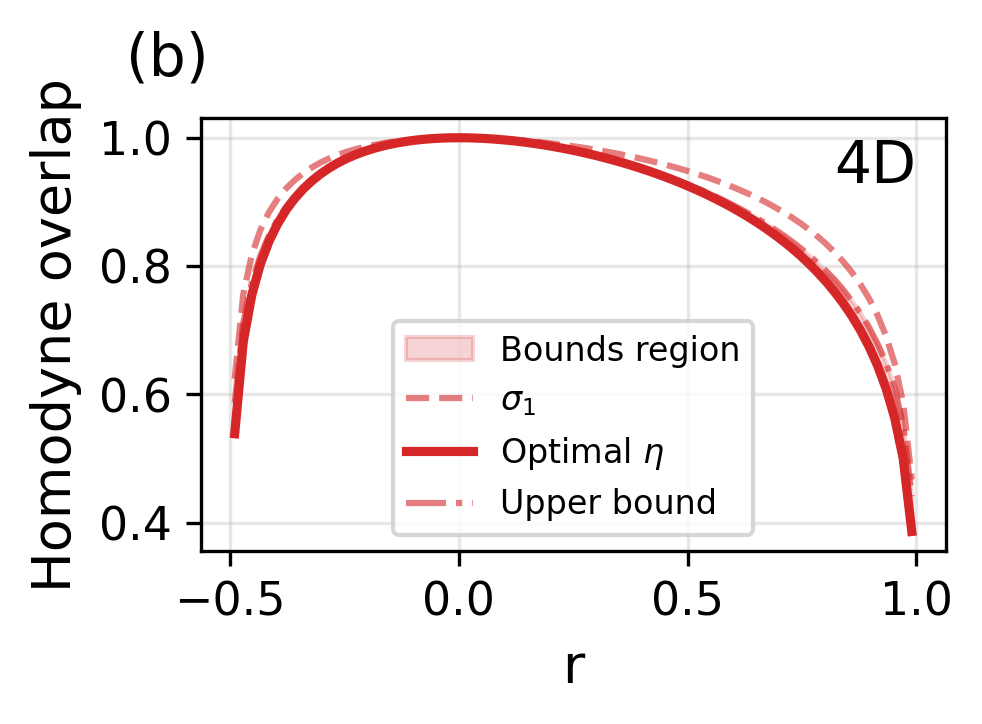

In [6]:
r_values = rho_values
sigma = jnp.array(sigma_list)
actual_value = jnp.array(eta_list)
upper_bound = jnp.array(upper_bound_list)


# plt.figure(figsize=(7,5))
fig, ax = plt.subplots(figsize=(3.4, 2.6))

base_color = "tab:red"  # choose any: "tab:red", "tab:green", etc.

# --- Shaded region between lower and upper ---
ax.fill_between(
    r_values,
    actual_value,
    upper_bound,
    color=base_color,
    alpha=0.2,
    label="Bounds region",
)

# --- Sigma 1 ---
ax.plot(
    r_values, sigma, color=base_color, alpha=0.6, linestyle="--", label=r"$\sigma_1$"
)

# --- Actual value ---
ax.plot(
    r_values,
    actual_value,
    color=base_color,
    alpha=1.0,
    linewidth=2.2,
    label=r"Optimal $\eta$",
)

# --- Upper bound ---
ax.plot(
    r_values,
    upper_bound,
    color=base_color,
    alpha=0.6,
    linestyle="-.",
    label=r"Upper bound",
)

# Internal tag for dimensionality (e.g., "3D")
ax.text(0.85, 0.85, "4D", transform=ax.transAxes, fontsize=14)

# Panel label (e.g., "(a)")
ax.text(-0.10, 1.1, "(b)", transform=ax.transAxes, fontsize=14)

ax.set_xlabel("r")
ax.set_ylabel("Homodyne overlap")
ax.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"Bound_gaussian_{d}D_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()

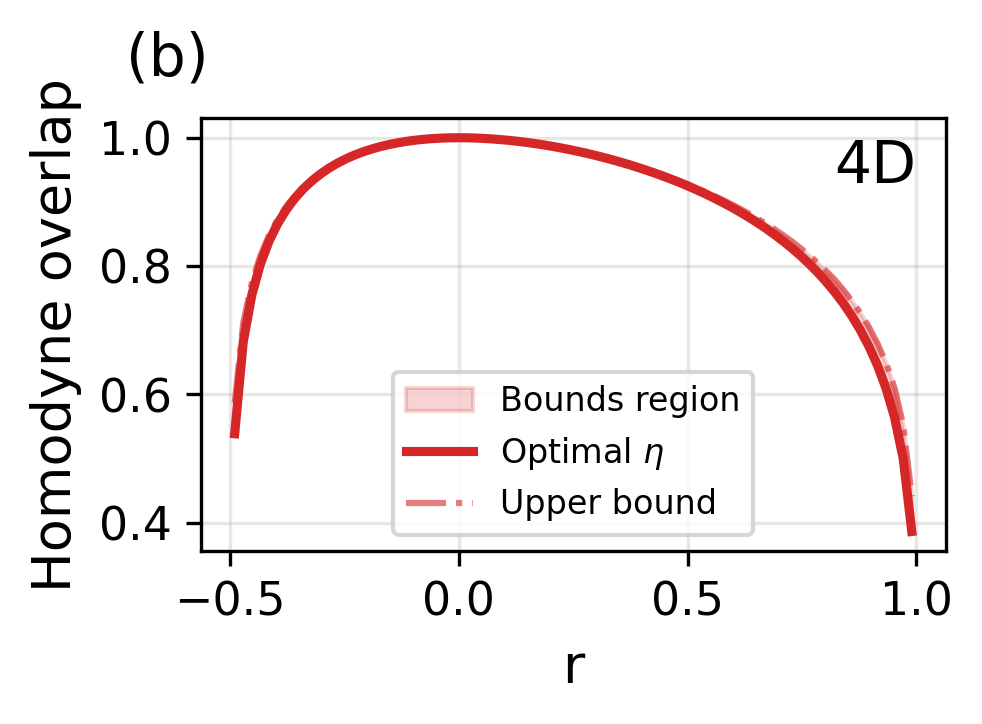

In [ ]:
# plt.figure(figsize=(7,5))
fig, ax = plt.subplots(figsize=(3.4, 2.6))

base_color = "tab:red"  # choose any: "tab:red", "tab:green", etc.

# --- Shaded region between lower and upper ---
ax.fill_between(
    r_values,
    actual_value,
    upper_bound,
    color=base_color,
    alpha=0.2,
    label="Bounds region",
)


# --- Actual value ---
ax.plot(
    r_values,
    actual_value,
    color=base_color,
    alpha=1.0,
    linewidth=2.2,
    label=r"Optimal $\eta$",
)

# --- Upper bound ---
ax.plot(
    r_values,
    upper_bound,
    color=base_color,
    alpha=0.6,
    linestyle="-.",
    label=r"Upper bound",
)

# Internal tag for dimensionality (e.g., "3D")
ax.text(0.85, 0.85, "4D", transform=ax.transAxes, fontsize=14)

# Panel label (e.g., "(a)")
ax.text(-0.10, 1.1, "(b)", transform=ax.transAxes, fontsize=14)

ax.set_xlabel("r")
ax.set_ylabel("Homodyne overlap")
ax.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"knapsack_bound_gaussian_{d}D_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()